In [1]:
%matplotlib inline

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Just a hack to unload PyNitride
# so I don't have to restart the kernel every time I change PyNitride code
import sys; [sys.modules.pop(k) for k in list(sys.modules) if 'pynitride' in k]
    
from pynitride.examples.pchannel_GaN_AlN_HFET.pFET_visualization import valence_band_panels
from pynitride.physics.material import AlGaN
from pynitride import Mesh, MaterialBlock, UniformLayer
from pynitride import to_unit, nm, eV, cm, meV
from pynitride import RMesh2D_Polar, RMesh1D
from pynitride import Simulation
from pynitride import log

In [13]:

def define_mesh(sim,well_t=15*nm,buff_t=200*nm,Ndd=5e16/cm**3,max_dz=5*nm,sbh=1.4*eV,ss=0*meV):

    # Set up the main mesh
    m=sim.dmeshes['main']=Mesh([
        MaterialBlock("epi",AlGaN(spin_splitting=ss),[
            UniformLayer("well"  ,  well_t, x=0, DeepDonorDonorConc=Ndd),
            UniformLayer("buffer",  buff_t, x=1, DeepDonorDonorConc=Ndd),
        ])],
        max_dz=max_dz,
        refinements=[[0,.03*nm,2],['well/buffer',.01*nm,1.5]],
        uniform=False,boundary=[sbh,"thick"])
    log("Mesh points " + str(m.Nn))

    # Set up a quantum mesh
    sim.dmeshes['mbkp'],sim.dmeshes['semi']=m.submesh_cover([well_t+5*nm],['mbkp','semi'])
    sim.rmeshes['mbkp_solve']=RMesh1D.regular(kmax=2.5/nm,numabsk=24)
    sim.rmeshes['mbkp_out'  ]=RMesh1D.regular(kmax=4.8/nm,numabsk=48)

    # Additional info
    sim.extras['well_t']=well_t
    sim.extras['sourcepoint']=float(well_t-2.5)

In [14]:
# OPTION A: Using an even spaced temperature interval
if False:
    t_start=300; t_stop=300; t_stop=10; t_step=10;
    num_t=int(np.round(np.abs((t_stop-t_start)/t_step)))+1
    assert np.isclose(np.abs(t_step)*(num_t-1),np.abs(t_stop-t_start)), "Make sure to provide an even-spaced step"
    t_points=np.linspace(t_start,t_stop,num_t,endpoint=True)

# OPTION B: Using an explicit list of temperatures
if True:
    t_points=[300,200,200,150,100,50,10]

In [16]:
sim=Simulation(f'pFET_Tsweep',define_mesh=define_mesh,
           solve_flow=Simulation.flow_semiclassicalramp_mbkp,
           solve_opts ={'T':t_start,'ramp_T':t_points,'mbkp_opts':{'num_eigenvalues':6},'Va':4,
                        'mbkp_loop_opts':{'init_activation':.1, 'inc_activation':1.3},
                        'Tramp_loop_opts':{'init_activation':.5,'inc_activation':1.3,'min_activation':.005}})

# Warning, this only checks for the final save file, and if it is found, the sim will be loaded instead of run.
# So if you, eg, change the intermediate temperatures, this won't know to re-run
# and also, the files from old temperatures from previous runs would still be sitting around
# In short, if you use force=False, you are responsible for cleaning up debris and knowing when something has changed.
sim.load(force=False)

2023-12-08 21:12:42.841067     Mesh points 580
2023-12-08 21:12:42.846226     Hoping to load previous run from pFET_Tsweep*
2023-12-08 21:12:42.847738       But [Errno 2] No such file or directory: 'pFET_Tsweep_direct.npz'
2023-12-08 21:12:42.848774     Starting solve:
2023-12-08 21:12:42.850810       Updating global mesh because of change in temperature
2023-12-08 21:12:42.891925       Starting eps factor ramp from 10000 to 1
2023-12-08 21:12:42.891925         Eps factor: 1.00e+04
2023-12-08 21:12:42.901463         Starting SC loop
2023-12-08 21:12:42.909483           iter:   0  err: 5.58e-01  activ: 1
2023-12-08 21:12:42.918002           iter:   1  err: 1.12e-01  activ: 1
2023-12-08 21:12:42.933560           iter:   2  err: 6.82e-03  activ: 1
2023-12-08 21:12:42.947641           iter:   3  err: 4.73e-05  activ: 1
2023-12-08 21:12:42.962709           iter:   4  err: 1.87e-07  activ: 1
2023-12-08 21:12:42.962709           Loop finished in  5 iterations with err=1.86659e-07
2023-12-08 2

c:\users\sbader\nondrive\pynitride\pynitride\physics\carriers.py:408: RuntimeWarning: overflow encountered in cosh
  sign*np.sum(self.rmesh['normsqs']/(2+2*np.cosh(eta))/kT.tpf(),axis=1))
c:\users\sbader\nondrive\pynitride\pynitride\physics\carriers.py:408: RuntimeWarning: overflow encountered in multiply
  sign*np.sum(self.rmesh['normsqs']/(2+2*np.cosh(eta))/kT.tpf(),axis=1))


2023-12-08 21:23:47.854313             iter:   1  err: 7.82e-04  activ: 0.65
2023-12-08 21:23:54.026381             iter:   2  err: 2.86e-04  activ: 0.845
2023-12-08 21:23:59.849582             iter:   3  err: 5.52e-05  activ: 1
2023-12-08 21:24:05.812641             iter:   4  err: 7.16e-06  activ: 1
2023-12-08 21:24:05.813614             Loop finished in  5 iterations with err=7.15782e-06
2023-12-08 21:24:05.814636           Temperature: 50.83
2023-12-08 21:24:05.815638           Updating global mesh because of change in temperature
2023-12-08 21:24:05.816647             Re-calling: _bandedge_params
2023-12-08 21:24:05.822373           Starting SC loop
2023-12-08 21:24:12.134693             iter:   0  err: 1.41e-03  activ: 0.5
2023-12-08 21:24:18.286502             iter:   1  err: 7.01e-04  activ: 0.65
2023-12-08 21:24:23.591997             iter:   2  err: 2.57e-04  activ: 0.845
2023-12-08 21:24:27.330505             iter:   3  err: 4.97e-05  activ: 1
2023-12-08 21:24:30.972093      

2023-12-08 21:42:09.412000     Mesh points 580
2023-12-08 21:42:09.418284     Hoping to load previous run from pFET_Tsweep_300*
2023-12-08 21:42:09.437846     Loaded
Temperature 300
Holes: 2.94 x10^13/cm^2
EV-EF [meV]: 406.36 meV
2023-12-08 21:42:12.340669     Mesh points 580
2023-12-08 21:42:12.344159     Hoping to load previous run from pFET_Tsweep_200*
2023-12-08 21:42:12.357596     Loaded
Temperature 200
Holes: 2.92 x10^13/cm^2
EV-EF [meV]: 412.93 meV
2023-12-08 21:42:16.306963     Mesh points 580
2023-12-08 21:42:16.315485     Hoping to load previous run from pFET_Tsweep_200*
2023-12-08 21:42:16.337043     Loaded
Temperature 200
Holes: 2.92 x10^13/cm^2
EV-EF [meV]: 412.93 meV
2023-12-08 21:42:19.522938     Mesh points 580
2023-12-08 21:42:19.526592     Hoping to load previous run from pFET_Tsweep_150*
2023-12-08 21:42:19.547740     Loaded
Temperature 150
Holes: 2.92 x10^13/cm^2
EV-EF [meV]: 415.22 meV
2023-12-08 21:42:22.348641     Mesh points 580
2023-12-08 21:42:22.350652     Ho

c:\users\sbader\nondrive\pynitride\pynitride\examples\pchannel_GaN_AlN_HFET\pFET_visualization.py:53: RuntimeWarning: overflow encountered in exp
  plt.fill_betweenx(E * 1e3, DOS * 1 / (1 + np.exp(-E / kT)), color=c, alpha=1)
c:\users\sbader\nondrive\pynitride\pynitride\examples\pchannel_GaN_AlN_HFET\pFET_visualization.py:116: RuntimeWarning: overflow encountered in exp
  plt.fill_between( absk, 1 / (1 + np.exp(-en / kT)), color=c)
c:\users\sbader\nondrive\pynitride\pynitride\examples\pchannel_GaN_AlN_HFET\pFET_visualization.py:119: RuntimeWarning: overflow encountered in exp
  plt.fill_between(-absk, 1 / (1 + np.exp(-en / kT)), color=c)


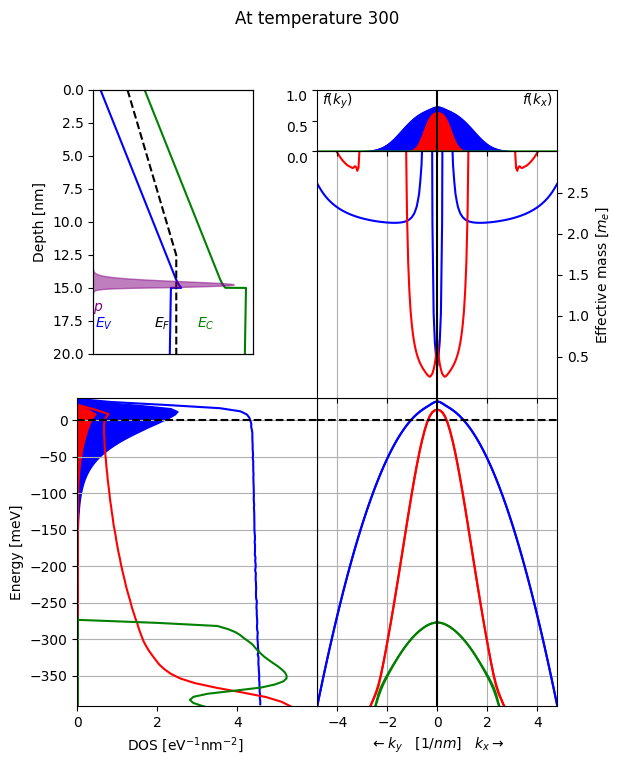

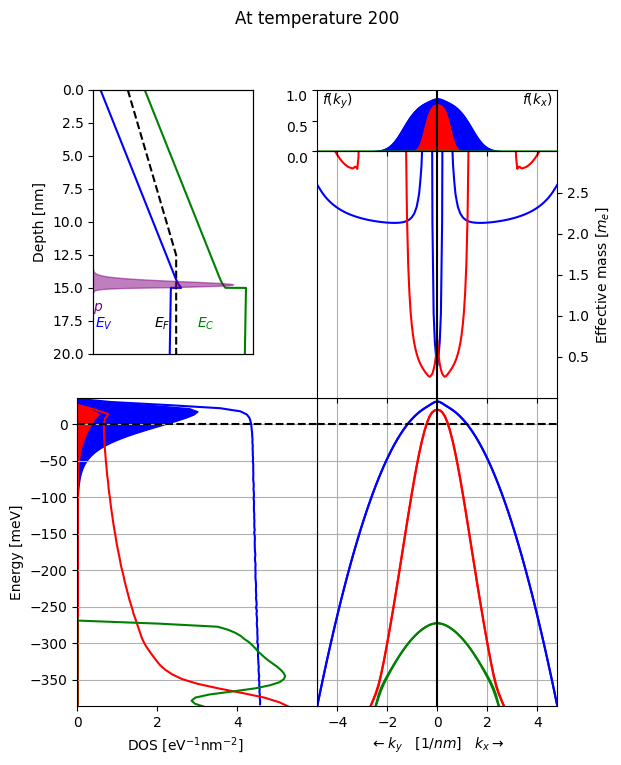

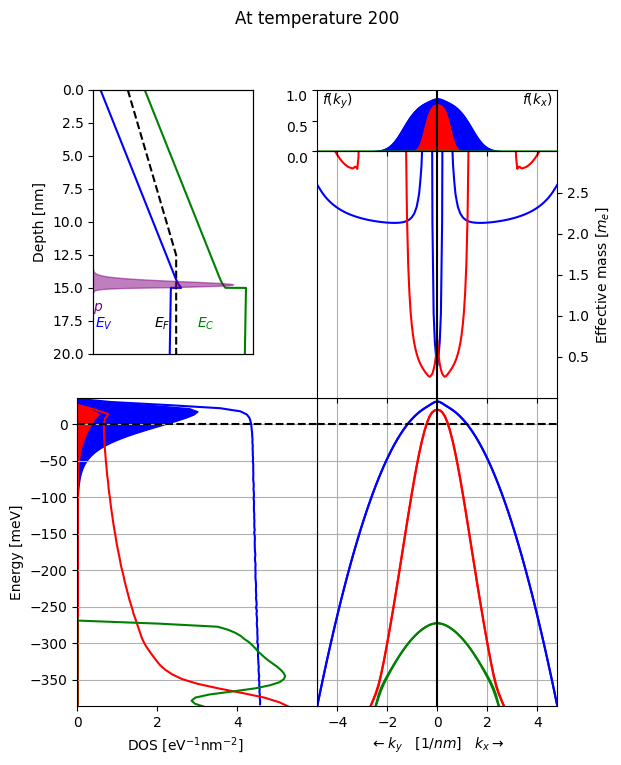

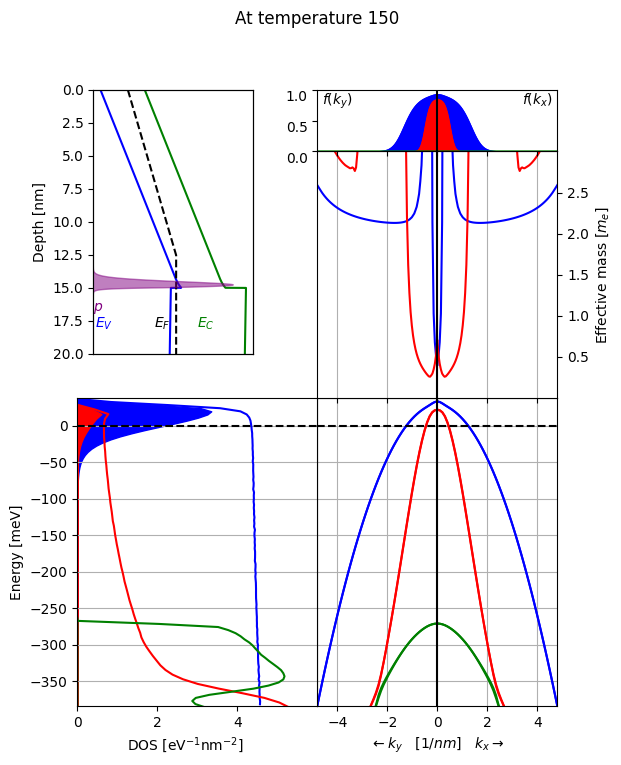

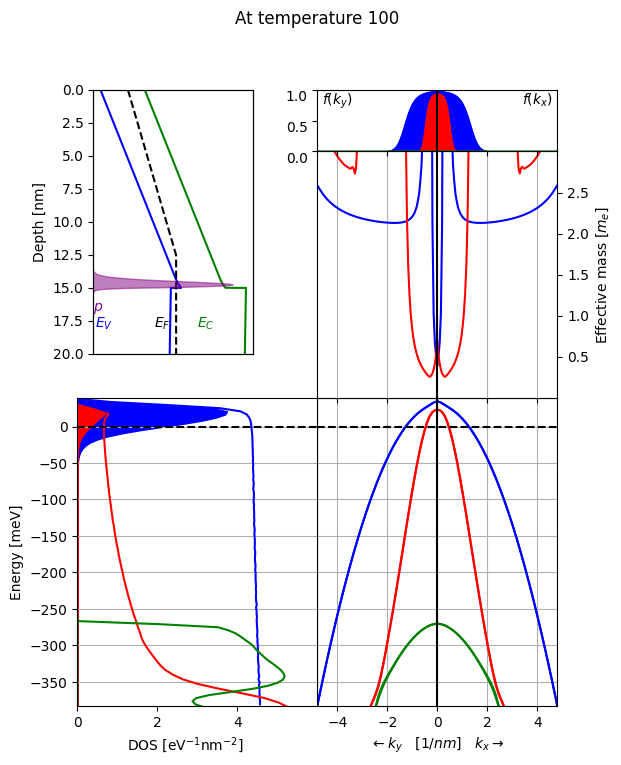

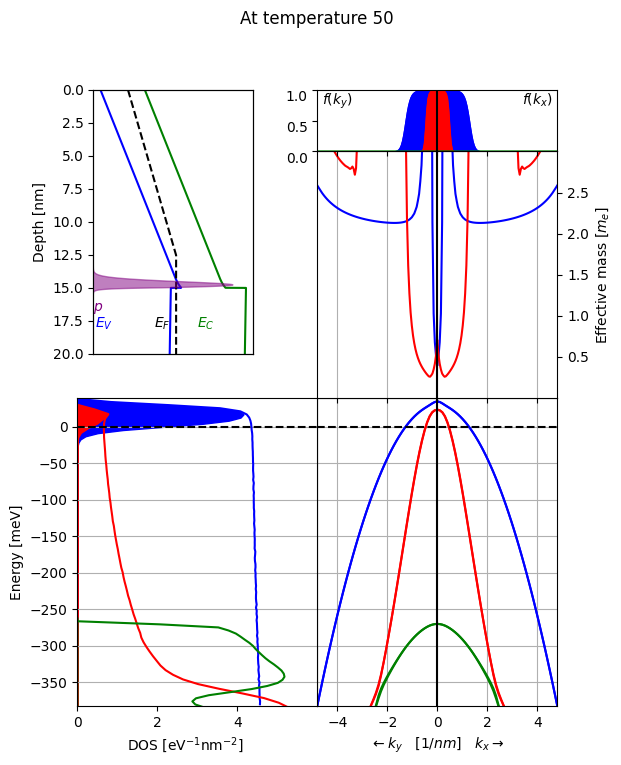

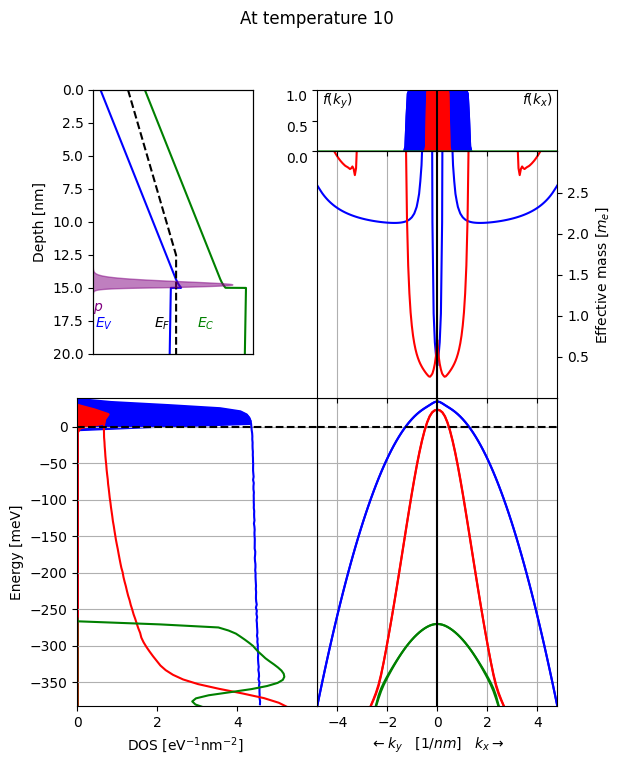

In [17]:
for T in t_points:
    sim=Simulation(f'pFET_Tsweep_{int(T):g}',define_mesh=define_mesh,solve_flow=None)
    sim.load(force=False)

    m,quantum=sim.dmeshes['main'],sim.dmeshes['mbkp']
    rmesh=sim.rmeshes['mbkp_out']

    print(f"Temperature {T}")
    print("Holes: {:.2f} x10^13/cm^2".format(to_unit(float(m.p.integrate(definite=True)),"1e13/cm^2")))
    print("EV-EF [meV]: {:.2f} meV".format(to_unit(float((m.Ev-m.EF.tmf())[m.indexm(sim.extras['well_t'])]),"meV")))
    
    from pynitride.physics.carriers import MultibandKP
    mbkp=MultibandKP(quantum,rmesh,num_eigenvalues=6)
    valence_band_panels(m,mbkp)
    plt.suptitle(f"At temperature {int(T):g}")